In [ ]:
# Aula 17 – Normalizing Flows: Coupling Flow on Two Spirals
# Complete version (professor)

# --- Imports ---
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)


Using device: cpu


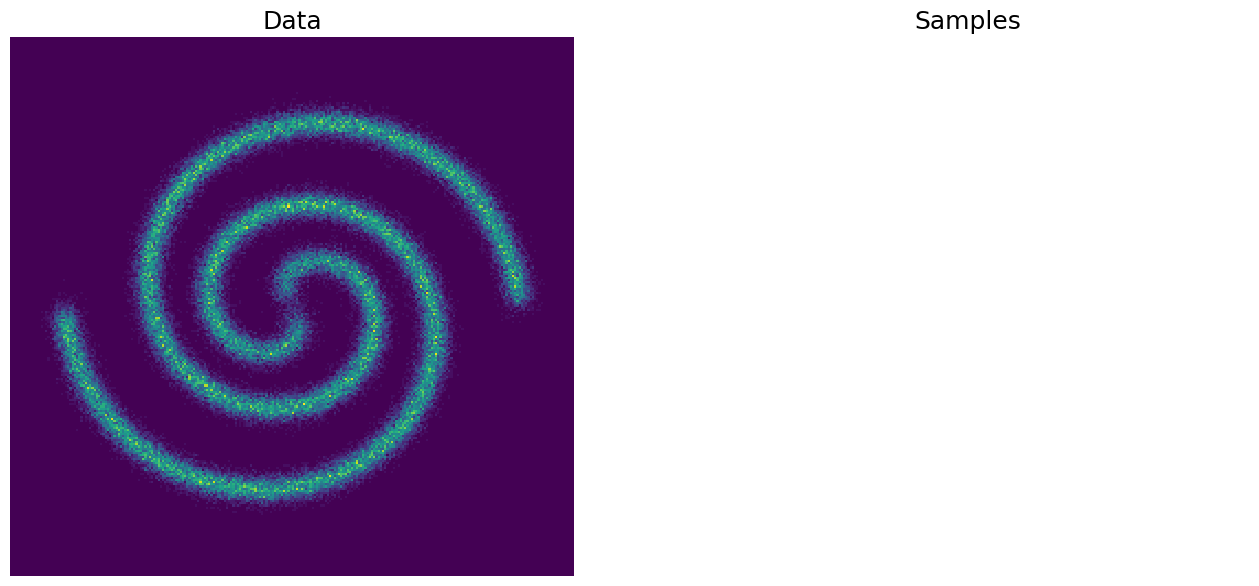

In [ ]:
# --- Dataset: TwoSpirals ---

class TwoSpirals(Dataset):
    def __init__(self, num_points):
        self.num_points = num_points
        self._create_data()

    def __getitem__(self, item):
        return self.data[item]

    def __len__(self):
        return self.num_points

    def _create_data(self):
        n = torch.sqrt(torch.rand(self.num_points // 2)) * 540 * (2 * np.pi) / 360
        d1x = -torch.cos(n) * n + torch.rand(self.num_points // 2) * 0.5
        d1y = torch.sin(n) * n + torch.rand(self.num_points // 2) * 0.5
        x = torch.cat([torch.stack([d1x, d1y]).t(),
                       torch.stack([-d1x, -d1y]).t()])
        self.data = x / 3 + torch.randn_like(x) * 0.1

train_loader = DataLoader(TwoSpirals(128000), batch_size=128, shuffle=True)
test_loader  = DataLoader(TwoSpirals(128000), batch_size=128, shuffle=False)

# --- Visualization helper ---

def plot_samples(s=None, title_data="Data", title_samples="Samples"):
    d = test_loader.dataset.data.numpy()
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 7))
    ax[0].axis('off')
    ax[1].axis('off')
    ax[0].set_title(title_data, fontsize=18)
    ax[1].set_title(title_samples, fontsize=18)

    ax[0].hist2d(d[...,0], d[...,1], bins=256, range=[[-4, 4], [-4, 4]])
    if s is not None:
        s = s.detach().cpu().numpy()
        ax[1].hist2d(s[...,0], s[...,1], bins=256, range=[[-4, 4], [-4, 4]])
    plt.show()

plot_samples()



In [ ]:
# --- Flow model definition ---

from torch.distributions import Normal

class Flow(nn.Module):
    def __init__(self, bijections):
        super().__init__()
        self.bijections = nn.ModuleList(bijections)

    @property
    def base_dist(self):
        return Normal(
            loc=torch.zeros(2, device=device),
            scale=torch.ones(2, device=device),
        )

    def log_prob(self, x):
        # x: (B, 2)
        log_prob = torch.zeros(x.shape[0], device=device)
        z = x
        for bijection in self.bijections:
            z, ldj = bijection(z)   # z: (B,2), ldj: (B,)
            log_prob += ldj
        log_prob += self.base_dist.log_prob(z).sum(1)  # sum over dim=2
        return log_prob

    def sample(self, num_samples):
        with torch.no_grad():
            z = self.base_dist.sample((num_samples,))  # (N, 2)
            for bijection in reversed(self.bijections):
                z = bijection.inverse(z)
        return z


In [ ]:
# --- Bijections: Reverse and Coupling ---

class Reverse(nn.Module):
    """
    Reverses the order of dimensions.
    For 2D: [x1, x2] -> [x2, x1].
    log-det Jacobian = 0.
    """
    def forward(self, x):
        return x.flip(-1), x.new_zeros(x.shape[0])

    def inverse(self, z):
        return z.flip(-1)


class Coupling(nn.Module):
    """
    RealNVP-style affine coupling layer for 2D inputs.
    We split x = [x1, x2], keep x1 as identity and
    apply an affine transform to x2 conditioned on x1.
    """

    def __init__(self, net):
        super().__init__()
        self.net = net  # takes x1 and outputs [shift, log_scale]

    def forward(self, x):
        """
        x -> z (data to base).
        Returns:
            z: transformed output (B, 2)
            ldj: log |det J| (B,)
        """


        z = ?

        # log det Jacobian: only x2 is scaled
        ldj = ?

        return z, ldj

    def inverse(self, z):
        """
        z -> x (base to data).
        """


        x1 = ?
        x2 = ?

        x = torch.cat([x1, x2], dim=1)
        return x


In [ ]:
# --- Network used inside Coupling ---

def make_net(hidden_dim=64, num_hidden_layers=2):
    """
    Small MLP: R^1 -> R^2
    Input: x1
    Output: [shift, log_scale] for x2
    """
    layers = []
    in_dim = 1
    out_dim = 2

    layers.append(nn.Linear(in_dim, hidden_dim))
    layers.append(nn.ReLU())
    for _ in range(num_hidden_layers - 1):
        layers.append(nn.Linear(hidden_dim, hidden_dim))
        layers.append(nn.ReLU())
    layers.append(nn.Linear(hidden_dim, out_dim))

    return nn.Sequential(*layers)


In [ ]:
# --- Instantiate the flow ---

flow = Flow([
    Coupling(make_net()).to(device), Reverse().to(device),
    Coupling(make_net()).to(device), Reverse().to(device),
    Coupling(make_net()).to(device), Reverse().to(device),
    Coupling(make_net()).to(device),
]).to(device)

print(flow)


Flow(
  (bijections): ModuleList(
    (0): Coupling(
      (net): Sequential(
        (0): Linear(in_features=1, out_features=64, bias=True)
        (1): ReLU()
        (2): Linear(in_features=64, out_features=64, bias=True)
        (3): ReLU()
        (4): Linear(in_features=64, out_features=2, bias=True)
      )
    )
    (1): Reverse()
    (2): Coupling(
      (net): Sequential(
        (0): Linear(in_features=1, out_features=64, bias=True)
        (1): ReLU()
        (2): Linear(in_features=64, out_features=64, bias=True)
        (3): ReLU()
        (4): Linear(in_features=64, out_features=2, bias=True)
      )
    )
    (3): Reverse()
    (4): Coupling(
      (net): Sequential(
        (0): Linear(in_features=1, out_features=64, bias=True)
        (1): ReLU()
        (2): Linear(in_features=64, out_features=64, bias=True)
        (3): ReLU()
        (4): Linear(in_features=64, out_features=2, bias=True)
      )
    )
    (5): Reverse()
    (6): Coupling(
      (net): Sequential(
 

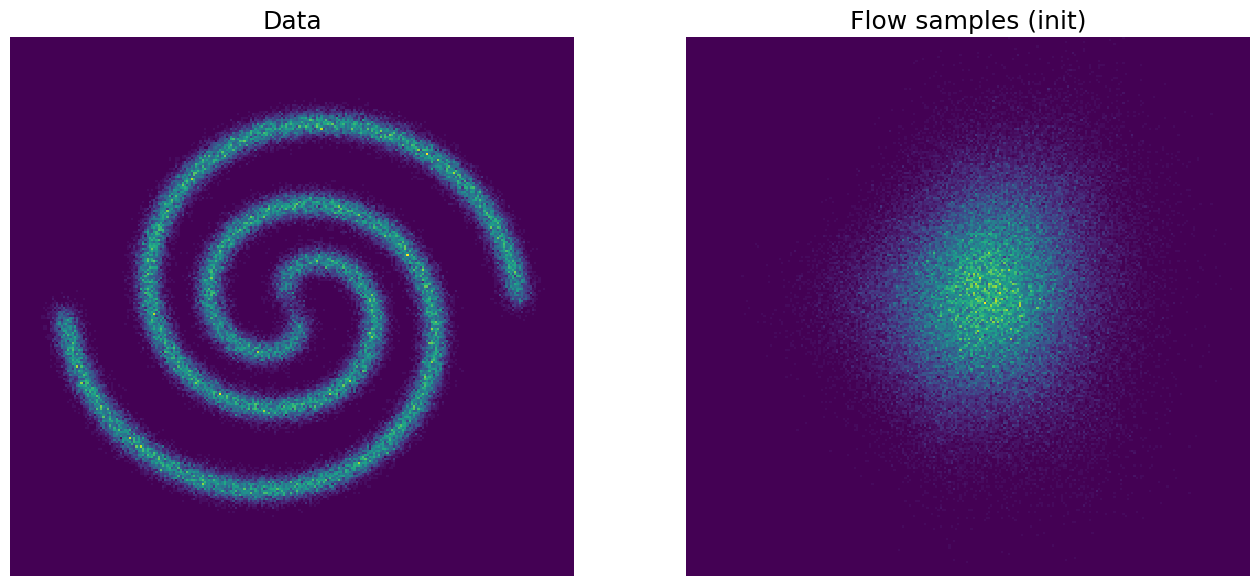

In [ ]:
# --- Plot model samples at initialization ---

with torch.no_grad():
    s0 = flow.sample(128000)

plot_samples(s0, title_data="Data", title_samples="Flow samples (init)")


In [ ]:
# --- Training loop ---

optimizer = torch.optim.Adam(flow.parameters(), lr=1e-3)
epochs = 10

print('Training...')
flow.train()
for epoch in range(epochs):
    loss_sum = 0.0
    for i, x in enumerate(train_loader):
        x = x.to(device)
        optimizer.zero_grad()
        loss = -flow.log_prob(x).mean()
        loss.backward()
        optimizer.step()
        loss_sum += loss.detach().cpu().item()
    print(f'Epoch: {epoch+1}/{epochs}, Loss: {loss_sum/len(train_loader):.3f}')

flow.eval()


Training...
Epoch: 1/10, Loss: 3.416
Epoch: 2/10, Loss: 3.278
Epoch: 3/10, Loss: 3.239
Epoch: 4/10, Loss: 3.215
Epoch: 5/10, Loss: 3.194
Epoch: 6/10, Loss: 3.159
Epoch: 7/10, Loss: 3.126
Epoch: 8/10, Loss: 3.145
Epoch: 9/10, Loss: 3.131
Epoch: 10/10, Loss: 3.174


Flow(
  (bijections): ModuleList(
    (0): Coupling(
      (net): Sequential(
        (0): Linear(in_features=1, out_features=64, bias=True)
        (1): ReLU()
        (2): Linear(in_features=64, out_features=64, bias=True)
        (3): ReLU()
        (4): Linear(in_features=64, out_features=2, bias=True)
      )
    )
    (1): Reverse()
    (2): Coupling(
      (net): Sequential(
        (0): Linear(in_features=1, out_features=64, bias=True)
        (1): ReLU()
        (2): Linear(in_features=64, out_features=64, bias=True)
        (3): ReLU()
        (4): Linear(in_features=64, out_features=2, bias=True)
      )
    )
    (3): Reverse()
    (4): Coupling(
      (net): Sequential(
        (0): Linear(in_features=1, out_features=64, bias=True)
        (1): ReLU()
        (2): Linear(in_features=64, out_features=64, bias=True)
        (3): ReLU()
        (4): Linear(in_features=64, out_features=2, bias=True)
      )
    )
    (5): Reverse()
    (6): Coupling(
      (net): Sequential(
 

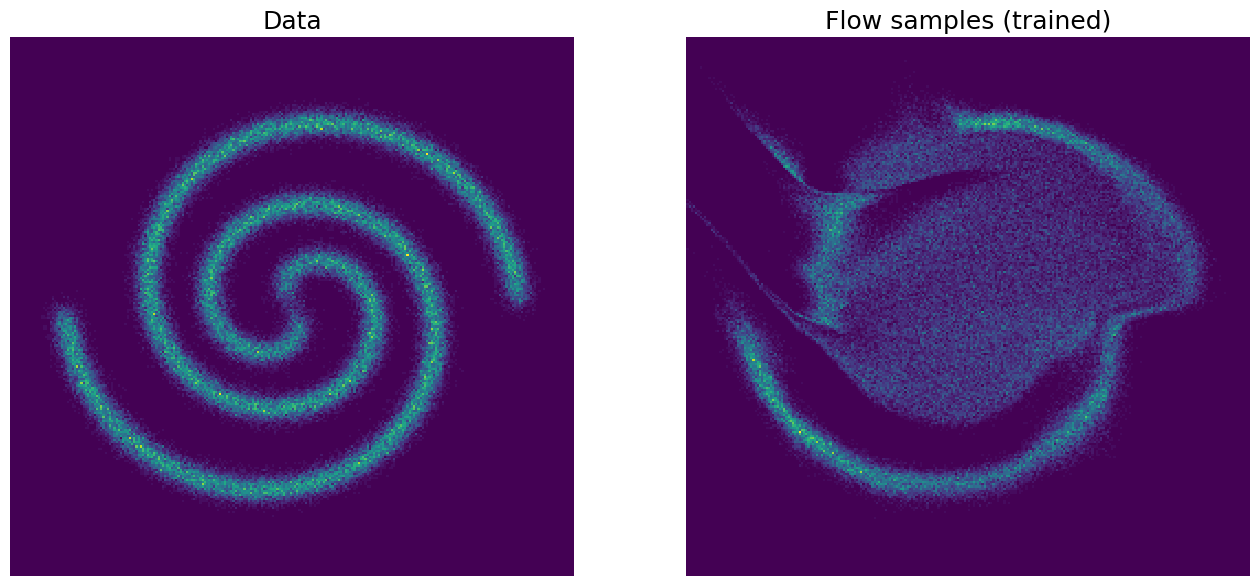

In [ ]:
# --- Plot model samples after training ---

with torch.no_grad():
    s = flow.sample(128000)

plot_samples(s, title_data="Data", title_samples="Flow samples (trained)")


[flow depth=2] Epoch 1/5, loss=3.627
[flow depth=2] Epoch 2/5, loss=3.482
[flow depth=2] Epoch 3/5, loss=3.461
[flow depth=2] Epoch 4/5, loss=3.450
[flow depth=2] Epoch 5/5, loss=3.440


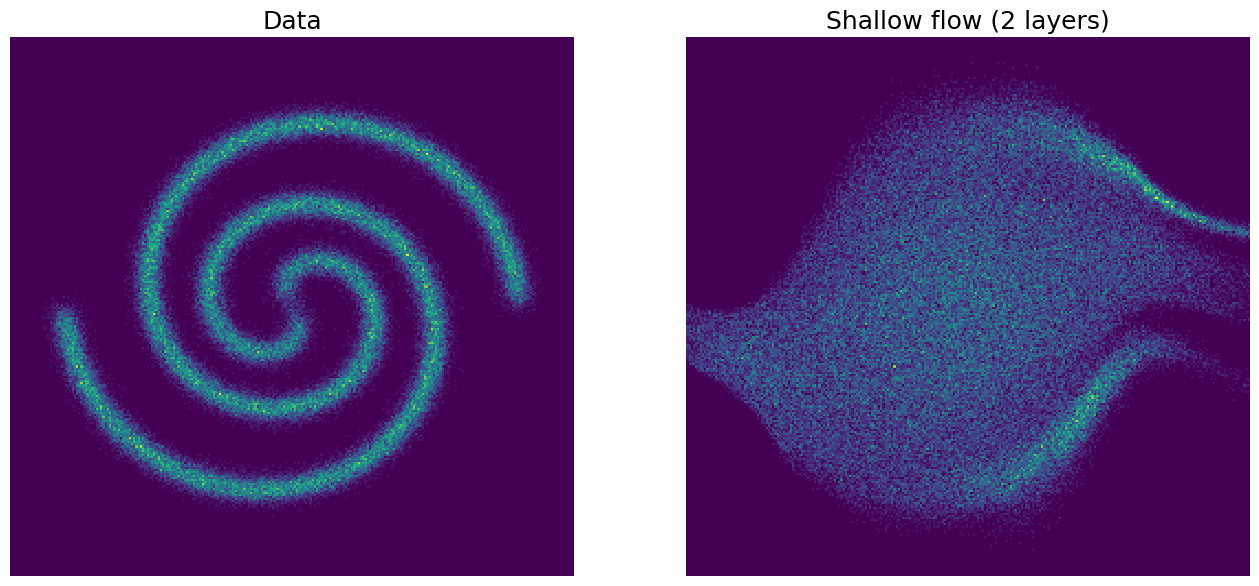

In [ ]:
# --- Bonus: simple function to experiment with hyperparameters ---

def train_flow(
    num_coupling_layers=4,
    hidden_dim=64,
    num_hidden_layers=2,
    lr=1e-3,
    epochs=5,
):
    bijections = []
    for i in range(num_coupling_layers):
        bijections.append(Coupling(make_net(hidden_dim, num_hidden_layers)).to(device))
        if i != num_coupling_layers - 1:
            bijections.append(Reverse().to(device))
    model = Flow(bijections).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=lr)

    model.train()
    for epoch in range(epochs):
        loss_sum = 0.0
        for x in train_loader:
            x = x.to(device)
            opt.zero_grad()
            loss = -model.log_prob(x).mean()
            loss.backward()
            opt.step()
            loss_sum += loss.detach().cpu().item()
        print(f'[flow depth={num_coupling_layers}] Epoch {epoch+1}/{epochs}, loss={loss_sum/len(train_loader):.3f}')
    model.eval()
    return model

# Example: shallower flow
small_flow = train_flow(num_coupling_layers=2, hidden_dim=32, num_hidden_layers=1, epochs=5)

with torch.no_grad():
    samples_small = small_flow.sample(128000)

plot_samples(samples_small, title_data="Data", title_samples="Shallow flow (2 layers)")
